In [1]:
import os
import sys
from datetime import datetime
from collections import OrderedDict
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

/home/sudur/new_anaconda3/envs/LabRotation/lib/python3.13/site-packages/numpy/_core/getlimits.py:548: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
source='jpl'
path_sh = "../data/JPL_input/"
# source='csr'
# path_sh = "../data/CSR_input/"
# source='itsg'
# path_sh = "../sample_input_data/ITSG_input/"

path_tn14 = "../pyshbundle/data/CSR_TN_files/TN-14_C30_C20_GSFC_SLR.txt"    # Path to TN14
path_tn13 = "../pyshbundle/data/CSR_TN_files/TN-13_GEOC_CSR_RL0602.txt"       # Path to TN13

In [3]:
from pyshbundle.hydro import TWSCalc
from pyshbundle.io import extract_SH_data, extract_deg1_coeff_tn13, extract_deg2_3_coeff_tn14
from pyshbundle.viz_utils import plot_calendar_months

Initializing PySHbundle v0.3.0


In [4]:
files = os.listdir(path_sh)
if str.upper(source) == 'ITSG':
    file_paths = [path_sh + file for file in files if os.path.splitext(file)[1] == '.gfc'];
else:
    file_paths = [path_sh + file for file in files if os.path.splitext(file)[1] == '.gz'];

In [5]:
extracted_data={} 
for file_path in file_paths:
    # file_data = read_sh(file_path, source=source)
    file_data = extract_SH_data(file_path, source=source)
    if file_data['time_coverage_start']:
        # Convert time_coverage_start to a datetime object and then format it as yyyy-mm
        if source == 'itsg':
            start_date = datetime.strptime(file_data['time_coverage_start'][-7:], '%Y-%m').strftime('%Y-%m')
        else:
            start_date = datetime.strptime(file_data['time_coverage_start'], '%Y-%m-%dT%H:%M:%S.%f').strftime('%Y-%m')
        # Use the formatted date as the key
        extracted_data[start_date] = file_data['coefficients']


# Time Sort the dictionary by keys (dates)
sorted_data = OrderedDict(sorted(extracted_data.items()));

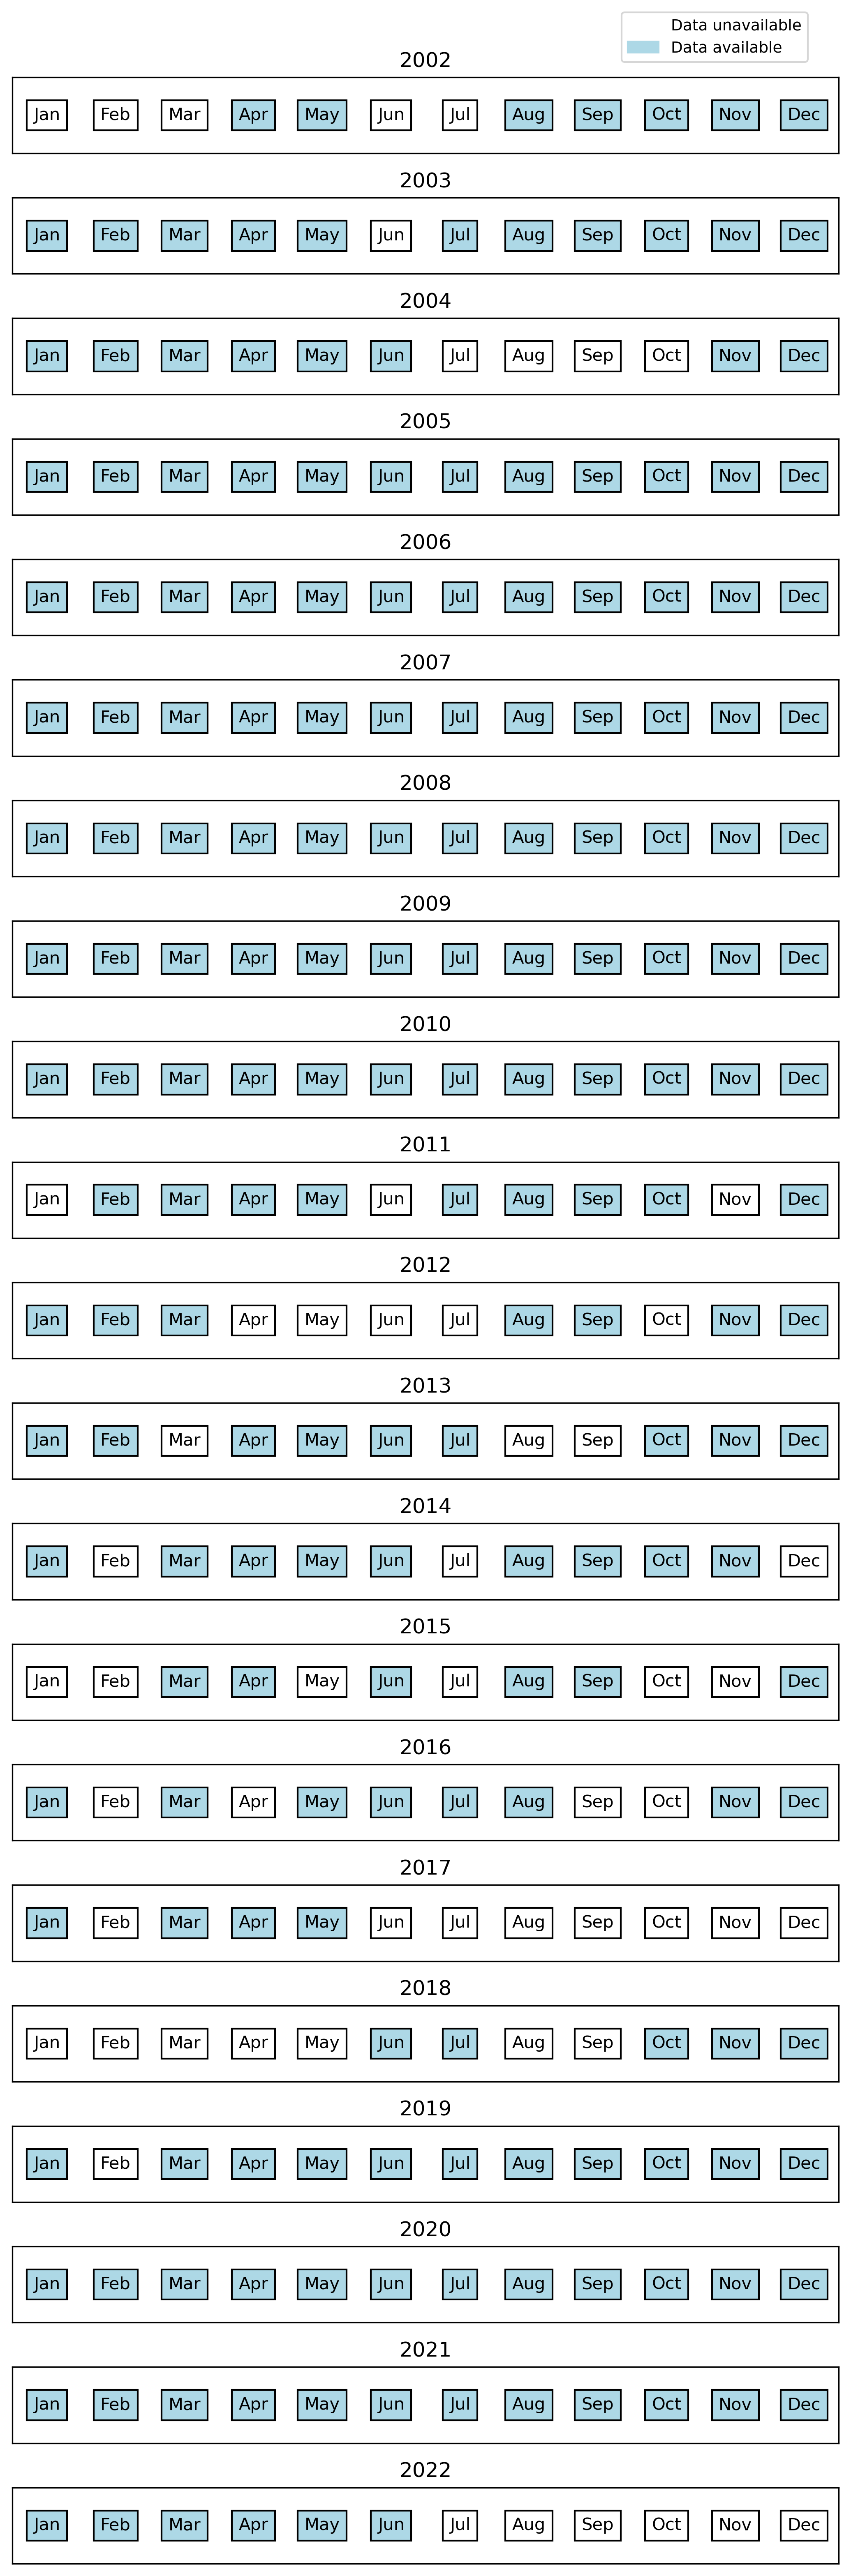

In [6]:
datetime_object = sorted_data.keys()

plot_calendar_months(datetime_object)

In [7]:
print(list(sorted_data.keys())[0:5], '\n')             # dicitonary for each year-month, printing only first 5
print(list(sorted_data['2002-04'].keys())[0:5], '\n')  # dictionary for each degree and order, , printing only first 5
print(sorted_data['2002-04'][(2,0)].keys(), '\n')      # dictionary with the data for repective year-month, degree and order
print('Clm value for (degree, order)=(2,0) is:', sorted_data['2002-04'][(2,0)]['Clm'])

['2002-04', '2002-05', '2002-08', '2002-09', '2002-10'] 

[(2, 0), (2, 1), (2, 2), (3, 0), (3, 1)] 

dict_keys(['Clm', 'Slm', 'Clm_sdev', 'Slm_sdev']) 

Clm value for (degree, order)=(2,0) is: -0.000484169317396


In [8]:
temp_tn14 = extract_deg2_3_coeff_tn14(path_tn14)

In [9]:
print('Keys of the TN14 replacement dictionary', list(temp_tn14.keys())[0:5],)        # dicitonary for each year-month, , printing only first 5
print('Keys of dictionary for year-month 2002-4', temp_tn14['2002-04'].keys())  # dictionary for c20, c30 coefficients for each year-month
print('For 2002-04 :',  '\n'
      'C20 is:', temp_tn14['2002-04']['c20'], '\n'
      'C30 is:',temp_tn14['2002-04']['c30'])

Keys of the TN14 replacement dictionary ['2002-04', '2002-05', '2002-08', '2002-09', '2002-10']
Keys of dictionary for year-month 2002-4 dict_keys(['year_frac_start', 'mjd_start', 'c20', 'c20_mean_diff', 'c20_sigma', 'c30', 'c30_mean_diff', 'c30_sigma', 'mjd_end', 'year_frac_end'])
For 2002-04 : 
C20 is: -0.00048416934147454 
C30 is: None


In [10]:
for date_key in temp_tn14.keys():
    if date_key in sorted_data.keys():
        sorted_data[date_key][(2,0)]['Clm'] = temp_tn14[date_key]['c20']
        if temp_tn14[date_key]['c30'] is not None:
            sorted_data[date_key][(3,0)]['Clm'] = temp_tn14[date_key]['c30'];

In [11]:
temp_tn13=extract_deg1_coeff_tn13(path_tn13)

In [12]:
print('Keys of the TN13 replacement dictionary', list(temp_tn13.keys())[0:5],)        # dicitonary for each year-month, printing only first 5
print('Keys of dictionary for year-month 2002-4', temp_tn13[('2002-04', 1, 0)].keys())  # dictionary for c20, c30 coefficients for each year-month
print('For 2002-04 :',  '\n'
       'C10 is:', temp_tn13[('2002-04', 1, 0)]['Clm'], '\n'
       'S10 is:', temp_tn13[('2002-04', 1, 0)]['Slm'], '\n'
       'C11 is:', temp_tn13[('2002-04', 1, 1)]['Clm'], '\n'
       'C11 is:', temp_tn13[('2002-04', 1, 1)]['Slm'])

Keys of the TN13 replacement dictionary [('2002-04', 1, 0), ('2002-04', 1, 1), ('2002-05', 1, 0), ('2002-05', 1, 1), ('2002-08', 1, 0)]
Keys of dictionary for year-month 2002-4 dict_keys(['degree', 'order', 'Clm', 'Slm', 'Clm_sdev', 'Slm_sdev', 'epoch_begin', 'epoch_end'])
For 2002-04 : 
C10 is: 5.120437146e-10 
S10 is: 0.0 
C11 is: 2.897447347e-10 
C11 is: -6.826708442e-11


In [13]:
if str.upper(source)=='JPL':
    for key in sorted_data:
        sorted_data[key][(0, 0)] = {'Clm': 0.0, 'Slm': 0.0, 'Clm_sdev': 0.0, 'Slm_sdev': 0.0}
        sorted_data[key][(1, 0)] = {'Clm': 0.0, 'Slm': 0.0, 'Clm_sdev': 0.0, 'Slm_sdev': 0.0}
        sorted_data[key][(1, 1)] = {'Clm': 0.0, 'Slm': 0.0, 'Clm_sdev': 0.0, 'Slm_sdev': 0.0};
else: pass

In [14]:
for date_key in temp_tn13.keys():
    if date_key[0] in sorted_data.keys():
        # print(date_key)
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Clm'] = temp_tn13[date_key]['Clm']
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Slm'] = temp_tn13[date_key]['Slm']
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Clm_sdev'] = temp_tn13[date_key]['Clm_sdev']
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Slm_sdev'] = temp_tn13[date_key]['Slm_sdev'];

In [15]:
max_degree=np.max([degree for date in sorted_data.keys() for degree, order in sorted_data[date].keys()])
max_order=np.max([order for date in sorted_data.keys() for degree, order in sorted_data[date].keys()])
number_of_months=len(sorted_data.keys())
print('The maximum degree & order in data is:' , max_degree, '&', max_order)
print('Number of months for which data is available:', number_of_months)

The maximum degree & order in data is: 96 & 96
Number of months for which data is available: 196


In [16]:
sc_mat=np.zeros([number_of_months, max_degree+1, 2*(max_degree+1)], dtype=np.double)

for index, key in enumerate(sorted_data.keys()):
    temp=sorted_data[key]
    for l in range(0,max_degree+1):
        for m in range(0,l+1):
            '''uncomment these two lines to see how the elements are being accessed from the dictionary'''
            # print(l,m)
            # print(temp[(l,m)]['Clm'])
            sc_mat[index, l, max_degree+m+1]=temp[(l,m)]['Clm']
            sc_mat[index, l, max_degree-m]=temp[(l,m)]['Slm']
    del temp

In [17]:
sc_mat=np.delete(sc_mat, max_degree, axis=2);

In [18]:
SH_long_mean_jpl = np.load('../pyshbundle/data/long_mean/SH_long_mean_jpl.npy')    # load the long term mean SH coeffs---> JPL 
SH_long_mean_csr = np.load('../pyshbundle/data/long_mean/SH_long_mean_csr.npy')    # load the long term mean SH coeffs---> CSR
SH_long_mean_itsg = np.load('../pyshbundle/data/long_mean/SH_long_mean_itsg.npy')    # load the long term mean SH coeffs---> ITSG
delta_sc=np.ones_like(sc_mat)*np.nan
if source== 'jpl':
    delta_sc = sc_mat -   SH_long_mean_jpl
    # delta_sc = sc_mat -   sc_mat.mean(axis=0)      # Remove the mean of the data
elif source== 'csr':
    delta_sc = sc_mat - SH_long_mean_csr
elif source== 'itsg':
    delta_sc = sc_mat - SH_long_mean_itsg

In [19]:
delta_sc

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -1.21434608e-10, ...,
          9.84888271e-11,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  1.73491178e-10, -3.28902648e-10, ...,
          2.31147571e-10, -1.32244919e-10,  0.00000000e+00],
        [ 9.24201951e-11, -4.23122552e-10,  3.07479334e-10, ...,
          2.26418058e-10,  1.72474302e-10, -7.94418139e-11]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e

In [20]:
 delta_sc.shape

(196, 97, 193)

## opening trend_sc_3d_jpl.nc file

In [21]:
trend_sc_3d = xr.open_dataset(r'IPM_Data/trend_sc_3d_jpl.nc')
trend_sc_3d

<xarray.Dataset> Size: 152kB
Dimensions:       (time: 1, degree: 97, order: 193)
Coordinates:
  * time          (time) int64 8B 0
  * degree        (degree) int64 776B 0 1 2 3 4 5 6 7 ... 90 91 92 93 94 95 96
  * order         (order) int64 2kB 0 1 2 3 4 5 6 ... 187 188 189 190 191 192
Data variables:
    trend_sc_jpl  (time, degree, order) float64 150kB ...

In [22]:
trend_sc_3d.trend_sc_jpl.values

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
         -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
         -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
        [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
          2.02613892e-12, -7.25083396e-13,  6.96307618e-14]]])

In [23]:
linear_trends_of_Stokes_coefficients = trend_sc_3d.trend_sc_jpl.values
linear_trends_of_Stokes_coefficients

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
         -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
         -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
        [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
          2.02613892e-12, -7.25083396e-13,  6.96307618e-14]]])

In [24]:
linear_trends_of_Stokes_coefficients.shape

(1, 97, 193)

In [25]:
import numpy as np

squeezed_array = np.squeeze(linear_trends_of_Stokes_coefficients)
squeezed_array

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
        -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
        -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
       [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
         2.02613892e-12, -7.25083396e-13,  6.96307618e-14]])

In [26]:
squeezed_array.shape

(97, 193)

In [27]:
trend_delta_sc = squeezed_array
trend_delta_sc

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
        -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
        -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
       [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
         2.02613892e-12, -7.25083396e-13,  6.96307618e-14]])

In [28]:
trend_delta_sc.shape

(97, 193)

In [29]:
trend_delta_sc_ready = trend_delta_sc[np.newaxis, :, :]
trend_delta_sc_ready

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
         -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
         -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
        [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
          2.02613892e-12, -7.25083396e-13,  6.96307618e-14]]])

In [30]:
trend_delta_sc_ready.shape

(1, 97, 193)

In [31]:
from pyshbundle.shutils import Gaussian
import matplotlib.pyplot as plt

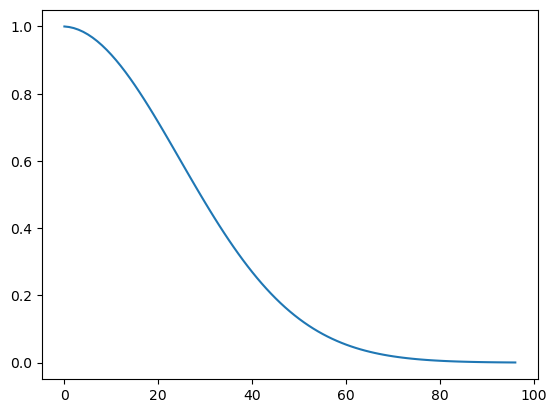

In [32]:
temp=Gaussian(L=96, cap=300);
plt.plot(temp)

In [33]:
# print('Kindly enter the following parameters based on your application')
# lmax = int(input("Enter lmax: "))
# gs = int(input("Enter grid size: "))
# half_rad_gf = int(input("Enter half radius of Gaussian filter: "))
# print("lmax , grid size & half raduius of gaussian filter are : ", lmax ,", " , gs,", ",half_rad_gf)
lmax,gs,half_rad_gf=96, 0.5, 300

In [34]:
number_of_months

196

In [35]:
linear_trends_of_Stokes_coefficients #no need to use squeezed one, we have already ready linear trend of the Stokes coefficients

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
         -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
         -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
        [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
          2.02613892e-12, -7.25083396e-13,  6.96307618e-14]]])

In [36]:
linear_trends_of_Stokes_coefficients.shape

(1, 97, 193)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.68it/s]


CPU times: user 438 ms, sys: 62.5 ms, total: 500 ms
Wall time: 345 ms


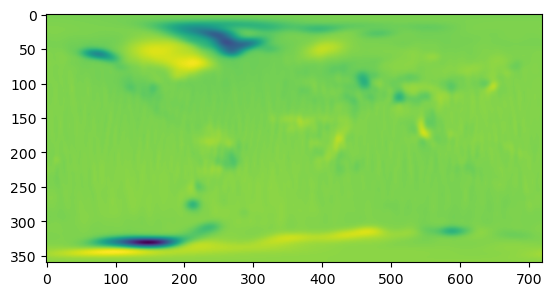

In [37]:
%%time
tws_fields_linear_trend_stokes_with_kn = TWSCalc(linear_trends_of_Stokes_coefficients, 96, 0.5, 300, 1) #1 = linear_trend of cnm, as we calculate for 1 month

In [38]:
tws_fields_linear_trend_stokes_with_kn.shape

(1, 360, 720)

In [39]:
tws_with_kn_in_secular_GRACE_stokes_coefficients = np.float32(tws_fields_linear_trend_stokes_with_kn) #tws_fields_noisy #tws_fields_noisy_ohne_love

In [41]:
lon = np.arange(-180,180,gs)
lat = np.arange(89,-91,-gs)
# dates = pd.to_datetime(list(sorted_data.keys()), format='%Y-%m',) \
#             + pd.offsets.MonthEnd(0)  #.dt.strftime('%d-%m-%Y')

ds_with_kn_in_secular_GRACE_stokes_coefficients = xr.Dataset(
    data_vars=dict(
        tws=(["time","lat", "lon"], tws_with_kn_in_secular_GRACE_stokes_coefficients, {"units": "mm"})
    ),
    coords = {
        # "time":(('time'),dates),
        # "time":dates,
        "lat":lat,
        "lon":lon },
    attrs=dict(description="Global gridded TWS Anomaly corresponding to long term (2004-2010) mean", 
               units="mm"),
)
ds_with_kn_in_secular_GRACE_stokes_coefficients

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 1, lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float64 3kB 89.0 88.5 88.0 87.5 ... -89.0 -89.5 -90.0 -90.5
  * lon      (lon) float64 6kB -180.0 -179.5 -179.0 -178.5 ... 178.5 179.0 179.5
Dimensions without coordinates: time
Data variables:
    tws      (time, lat, lon) float32 1MB -2.281 -2.282 -2.283 ... 7.436 7.437
Attributes:
    description:  Global gridded TWS Anomaly corresponding to long term (2004...
    units:        mm

In [46]:
ds_with_kn_in_secular_GRACE_stokes_coefficients.to_netcdf('../examples/tws_with_kn_in_secular_GRACE_stokes_coefficients.nc')